# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tabassumrafiq/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Ranked action logic

The action queue uses the model's observed decline score as a prioritization signal.

A higher score moves an item higher in the review queue. The score is not treated as proof that content will decline, and the reason codes are directional signals rather than causal explanations.

The ranking is intended to help a human reviewer decide which content should receive attention first.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

# Load the same dataset used in ML-09
url = "https://raw.githubusercontent.com/tabassumrafiq/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

data = pd.read_csv(url)

print("Dataset shape:", data.shape)

# Same validated feature set from ML-09
features = [
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "word_count"
]

# Same target definition from ML-09
data["is_declining_label"] = (
    data["trend_direction"] == "down"
).astype(int)

X = data[features].copy()
y = data["is_declining_label"].copy()

print("Features:", features)
print("Rows:", len(data))
print("Base rate:", round(y.mean(), 4))

Dataset shape: (30000, 44)
Features: ['avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'word_count']
Rows: 30000
Base rate: 0.5421


In [2]:
# Recreate the Random Forest model used in ML-09

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

model.fit(X, y)

# Generate model scores for the action queue
data["decline_score"] = model.predict_proba(X)[:, 1]

print("Predictions generated successfully.")
display(
    data[
        ["content_id", "decline_score"]
    ].head(10)
)

Predictions generated successfully.


,content_id,decline_score
0,content_304f48230142,0.463380
1,content_a1fb4e703a9e,0.641839
2,content_9aa793d4d895,0.727598
3,content_331d6c4de07b,0.496989
4,content_d99b7a2d90ca,0.605949
5,content_d4084a4bc775,0.699698
6,content_9a34b442b552,0.603453
7,content_a63219c6e95a,0.544423
8,content_5e6c160719bc,0.609618
9,content_c27558df2b0c,0.566428


In [3]:
# Use dataset medians as simple directional thresholds
median_position = data["avg_position"].median()
median_ctr = data["ctr"].median()
median_engagement = data["engagement_rate"].median()

def assign_reason_codes(row):
    reasons = []

    if row["decline_score"] >= 0.70:
        reasons.append("HIGH_DECLINE_SCORE")

    if row["engagement_rate"] < median_engagement:
        reasons.append("LOW_ENGAGEMENT_SIGNAL")

    if row["ctr"] < median_ctr:
        reasons.append("LOW_CTR_SIGNAL")

    if row["avg_position"] > median_position:
        reasons.append("POSITION_RISK")

    if not reasons:
        reasons.append("LOWER_PRIORITY")

    return "|".join(reasons)


data["reason_code"] = data.apply(
    assign_reason_codes,
    axis=1
)

display(
    data[
        [
            "content_id",
            "decline_score",
            "reason_code"
        ]
    ].head(10)
)

,content_id,decline_score,reason_code
0,content_304f48230142,0.463380,LOWER_PRIORITY
1,content_a1fb4e703a9e,0.641839,LOW_CTR_SIGNAL|POSITION_RISK
2,content_9aa793d4d895,0.727598,HIGH_DECLINE_SCORE|POSITION_RISK
3,content_331d6c4de07b,0.496989,LOWER_PRIORITY
4,content_d99b7a2d90ca,0.605949,POSITION_RISK
5,content_d4084a4bc775,0.699698,LOW_CTR_SIGNAL
6,content_9a34b442b552,0.603453,LOW_CTR_SIGNAL
7,content_a63219c6e95a,0.544423,LOW_CTR_SIGNAL|POSITION_RISK
8,content_5e6c160719bc,0.609618,POSITION_RISK
9,content_c27558df2b0c,0.566428,LOWER_PRIORITY


In [4]:
def assign_action(score):
    if score >= 0.70:
        return "PRIORITIZE_FOR_HUMAN_REVIEW"
    elif score >= 0.55:
        return "REVIEW_IF_RESOURCES_ALLOW"
    else:
        return "MONITOR"

data["recommended_action"] = data["decline_score"].apply(
    assign_action
)

print("Recommended actions created.")

display(
    data[
        [
            "content_id",
            "decline_score",
            "reason_code",
            "recommended_action"
        ]
    ].head(15)
)

Recommended actions created.


,content_id,decline_score,reason_code,recommended_action
0,content_304f48230142,0.463380,LOWER_PRIORITY,MONITOR
1,content_a1fb4e703a9e,0.641839,LOW_CTR_SIGNAL|POSITION_RISK,REVIEW_IF_RESOURCES_ALLOW
2,content_9aa793d4d895,0.727598,HIGH_DECLINE_SCORE|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW
3,content_331d6c4de07b,0.496989,LOWER_PRIORITY,MONITOR
4,content_d99b7a2d90ca,0.605949,POSITION_RISK,REVIEW_IF_RESOURCES_ALLOW
5,content_d4084a4bc775,0.699698,LOW_CTR_SIGNAL,REVIEW_IF_RESOURCES_ALLOW
6,content_9a34b442b552,0.603453,LOW_CTR_SIGNAL,REVIEW_IF_RESOURCES_ALLOW
7,content_a63219c6e95a,0.544423,LOW_CTR_SIGNAL|POSITION_RISK,MONITOR
8,content_5e6c160719bc,0.609618,POSITION_RISK,REVIEW_IF_RESOURCES_ALLOW
9,content_c27558df2b0c,0.566428,LOWER_PRIORITY,REVIEW_IF_RESOURCES_ALLOW


In [5]:
ranked_queue = data[
    [
        "content_id",
        "decline_score",
        "reason_code",
        "recommended_action",
        "avg_position",
        "ctr",
        "engagement_rate",
        "scroll_rate",
        "word_count"
    ]
].copy()

ranked_queue = ranked_queue.sort_values(
    by="decline_score",
    ascending=False
).reset_index(drop=True)

ranked_queue.insert(
    0,
    "priority_rank",
    np.arange(1, len(ranked_queue) + 1)
)

print("Top 20 prioritized actions:")
display(ranked_queue.head(20))

Top 20 prioritized actions:


,priority_rank,content_id,decline_score,reason_code,recommended_action,avg_position,ctr,engagement_rate,scroll_rate,word_count
0,1,content_66b4046cc144,0.763838,HIGH_DECLINE_SCORE|LOW_CTR_SIGNAL|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,26.6,0.03,1.35,41.67,5502.0
1,2,content_7a21f1aac586,0.761573,HIGH_DECLINE_SCORE|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,19.4,0.07,4.17,40.74,4159.0
2,3,content_14b6d37d9577,0.759976,HIGH_DECLINE_SCORE|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,33.9,0.11,3.85,38.71,4471.0
3,4,content_69884e990157,0.759843,HIGH_DECLINE_SCORE|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,31.4,0.08,1.33,34.67,5666.0
4,5,content_551fe371f51b,0.759622,HIGH_DECLINE_SCORE|LOW_CTR_SIGNAL|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,23.8,0.04,4.17,35.19,3698.0
5,6,content_341b1ecdea85,0.759596,HIGH_DECLINE_SCORE|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,24.2,0.08,2.33,49.09,4012.0
6,7,content_7158cfbbc450,0.759112,HIGH_DECLINE_SCORE|LOW_CTR_SIGNAL|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,24.9,0.06,3.03,45.92,3955.0
7,8,content_964dd0100c99,0.758854,HIGH_DECLINE_SCORE|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,22.2,0.09,2.22,42.31,4320.0
8,9,content_6eeb07cca243,0.757159,HIGH_DECLINE_SCORE|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,26.9,0.09,2.78,33.33,4107.0
9,10,content_a27e15f618c2,0.757070,HIGH_DECLINE_SCORE|POSITION_RISK,PRIORITIZE_FOR_HUMAN_REVIEW,32.5,0.14,4.65,43.48,4107.0


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

This playbook is intended for research and decision-support use by a human content reviewer.

The ranked queue helps prioritize which content items may deserve review first, using observed model scores and directional content signals.

### Limits

The model does not establish that a content item will definitely decline. It also does not establish that refreshing a flagged item will improve its future performance.

The client-grouped validation result is treated as the more conservative estimate for generalization to unseen clients. In ML-09, the grouped split produced an F1 score of 0.6730 and had zero client overlap between training and test sets.

The playbook is therefore a prioritization aid, not a production decision-making system.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review rules

A human reviewer should check a recommendation before taking action.

The reviewer should consider:

- Current content quality and relevance.
- Whether the observed model signal is consistent with the current context.
- Whether the content has strategic importance.
- Whether there are recent changes that are not represented in the model.
- Whether a refresh is actually appropriate.
- Whether the recommendation is based on a sufficiently clear signal.

### No-go list

The following should not be automated:

- Automatically rewriting published content.
- Automatically deleting content.
- Automatically publishing changes.
- Automatically treating a model score as a guaranteed future outcome.
- Automatically claiming that a refresh will improve performance.
- Automatically acting on ambiguous or sensitive cases.
- Automatically replacing human editorial judgment.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring

The action playbook should be monitored for changes in:

- Model performance.
- Precision@K.
- Decline-label base rate.
- Distribution of model scores.
- Feature distributions.
- Number of items receiving high-priority recommendations.
- Human review outcomes.

### Retrain triggers

Retraining should be considered when:

- The client or content population changes materially.
- Feature distributions shift materially.
- The decline base rate changes materially.
- Precision@K decreases consistently.
- Grouped validation performance deteriorates.
- New labeled observations become available.
- The relationship between observed signals and the decline label changes.

A single incorrect recommendation should not by itself trigger retraining.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## 5. Exports for the paper

The ranked action queue is regenerated by the notebook rather than committed as a data file.

The reusable figure and metrics receipt are exported so that the research paper can trace its recommendations back to this notebook.

In [6]:
# Create output and figure directories

outputs_dir = Path("../outputs")
figures_dir = Path("../figures")

outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Output directories ready.")

Output directories ready.


In [7]:
queue_path = outputs_dir / "ranked_action_queue.csv"

ranked_queue.to_csv(
    queue_path,
    index=False
)

print("Queue exported to:", queue_path)
print("Rows:", len(ranked_queue))

Queue exported to: ../outputs/ranked_action_queue.csv
Rows: 30000


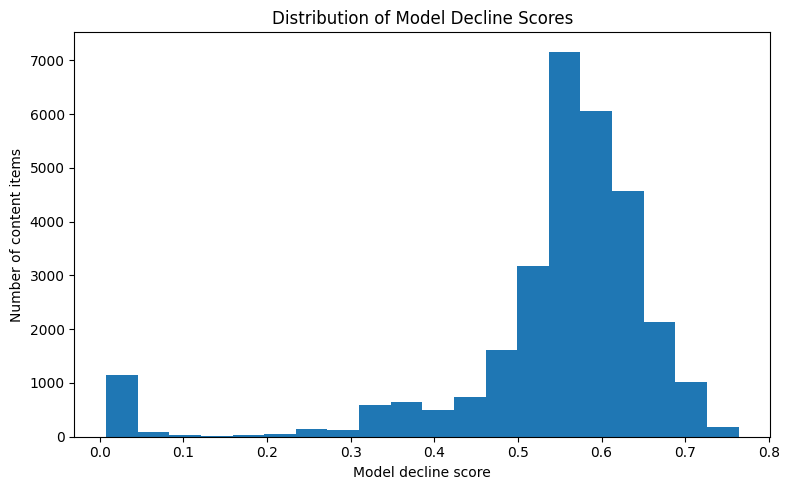

Figure exported to: ../figures/decline_score_distribution.png


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    data["decline_score"],
    bins=20
)

plt.xlabel("Model decline score")
plt.ylabel("Number of content items")
plt.title("Distribution of Model Decline Scores")

plt.tight_layout()

figure_path = figures_dir / "decline_score_distribution.png"

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure exported to:", figure_path)

In [9]:
import json

metrics = {
    "dataset_rows": 30000,
    "overall_base_rate": 0.5421,
    "random_split": {
        "accuracy": 0.6352,
        "precision": 0.6121,
        "recall": 0.8924,
        "f1": 0.7261
    },
    "client_grouped_split": {
        "accuracy": 0.5398,
        "precision": 0.5283,
        "recall": 0.9270,
        "f1": 0.6730
    },
    "client_overlap": 0,
    "intended_use": "decision-support for human review"
}

metrics_path = outputs_dir / "ml10_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics exported to:", metrics_path)

Metrics exported to: ../outputs/ml10_metrics.json


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [10]:
checks = {
    "ranked_queue_created": len(ranked_queue) > 0,
    "priority_rank_present": "priority_rank" in ranked_queue.columns,
    "reason_code_present": "reason_code" in ranked_queue.columns,
    "action_present": "recommended_action" in ranked_queue.columns,
    "score_present": "decline_score" in ranked_queue.columns,
    "queue_export_exists": queue_path.exists(),
    "figure_export_exists": figure_path.exists(),
    "metrics_export_exists": metrics_path.exists()
}

for name, passed in checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")

assert all(checks.values())

print("\nML-10 self-check: PASS")

ranked_queue_created: PASS
priority_rank_present: PASS
reason_code_present: PASS
action_present: PASS
score_present: PASS
queue_export_exists: PASS
figure_export_exists: PASS
metrics_export_exists: PASS

ML-10 self-check: PASS
